# Neural Network Offline Training

In [1]:
import sys
sys.path.insert(0, '../OSSWEM_helpers')
# sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import numpy as np
from OSSWEM_obc_orlanski import SSWEM                 # 1D Orlanski scheme (r_x only)
# from OSSWEM_obc_orlanski_2D import SSWEM as SSWEM_2D  # [1D-2D] 2D oblique Orlanski (adds r_y)

import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')   # avoid libiomp clash (torch + numpy/MKL)
import sys
sys.path.insert(0, 'helper')                            # local differentiable scheme
import torch
from torch import nn
sys.path.insert(0, '../helper')
from orlanski_scheme import orlanski_east_update, orlanski_east_analytic

# Parameters

mesh: ni = 120  nj = 120
Grid: dx = 10000.0 [m]  dy = 10000.0 [m]
cg = 8.0 [m s-1]
Ld = 80000.0 [m]
Scales: Ls=epsilon/D/beta = 1041.6666666666667 [m]
Scales: Lx/Ld = 15.0
Res: Ld/dx = 8.0
Res: Ls/dx = 0.10416666666666667


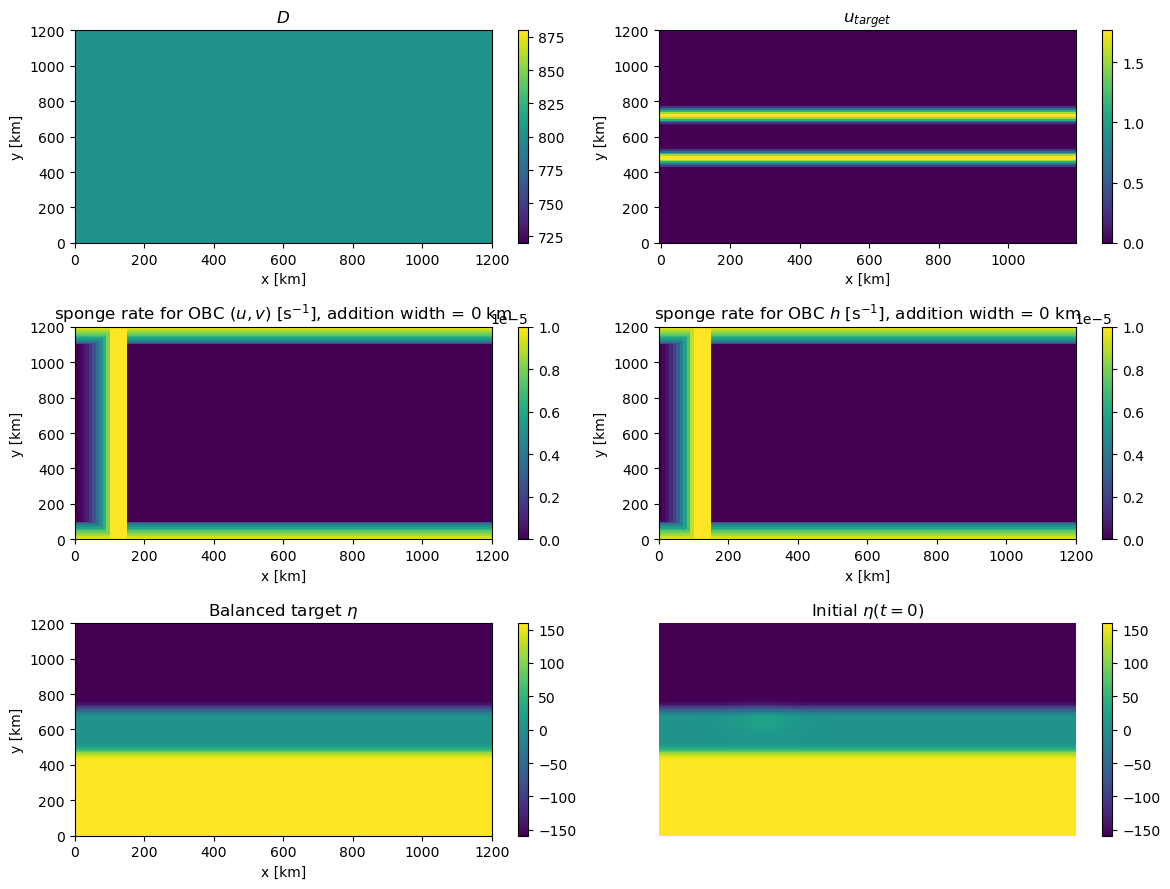

In [2]:
# Barotropic instability in a channel: a balanced zonal jet maintained by a
# localized western sponge (beta-plane).

# nj, ru_params = [dt, steps/segment, segments]
# nj, run_params = 40, [200., 500, 25]  # Barely permitted eddies
nj, run_params = 120, [100., 500, 200]  # Coarsest resolution with good instabilities
# nj, run_params = 120, [50., 2000, 100]  # Finer resolution
# nj, run_params = 180, [5., 5000, 100]  # Finer resolution is very unstable

M = SSWEM(nj,
          0.08,    # Gravity [m s-2]
          800.,    # Nominal layer thickness [m]
          1200.e3,  # Domain width [m]  (50% longer in x than y)
          1.e-4,   # Coriolis [s-1]
          3.0e-11, # df/dy [m-1 s-1]  (beta-plane arrests the large-scale meridional mode)
          2.5e-5,  # Bottom drag rate [m s-1]
          2e2,     # Lateral viscosity [m2 s-1]
          nj=nj    # Rectangular channel
          )
# M.D[0,:] = 0       # dry rows N/S -> zonal channel walls
# M.D[-1,:] = 0

# Target zonal jet and its geostrophically balanced free surface (f u = -g d(eta)/dy)
# M.set_u_target_jet(1.0)                            # u_target = jet(y)

# Double jet
yc = M.yu / M.Ly                                   # non-dim y at u-points
hw = 60e3 / M.Ly                                   # half-width of each jet (< Ly/6 so they don't overlap)
bump = lambda c: SSWEM._cubint(yc, c-hw, c) - SSWEM._cubint(yc, c, c+hw)
profile = 1.8 * (bump(2/5) + bump(3/5))                   # two eastward jets at y = 2Ly/5, 3Ly/5
M.u_target = np.empty_like(M.u)
for k in range(M.nk):
    M.u_target[k, :] = 1.0 * profile               # 1.0 = peak speed [m/s]


uy  = M.u_target[0].mean(axis=1)                   # u(y)
f_h = M.fo + M.beta * M.yh1                        # f(y) at row centres
eta = -(1.0/M.g[0]) * np.cumsum(f_h * uy) * M.dy
eta -= eta.mean() # Why remove mean? 
hbal = np.maximum(M.D + eta[:, None], 0.0)         # balanced thickness
hbal[0, :] = hbal[1, 1]
hbal[-1, :] = hbal[-2, 1]

# ============================= Sponge Layer Setup ==============================================

# Sponges restoring u->jet, v->0, h->balanced: a western sponge over the westernmost
# 150 km, plus N/S near-wall sponges over the outer 100 km.
# Local forcing only; the rest of the domain is free to evolve.
factor = 1.5
def ramp(x, x0, Lx, p=0.5): return np.clip((x - x0)/(Lx - x0), 0, 1)**p
def ramp2(x, x0, Lx, factor=1.5): return np.clip(factor*(x - x0)/(Lx - x0), 0, 1)**2
# rate, Lw, yb = 1.0e-5, 150.e3, 100e3               # western sponge width Lw; near-wall band yb
rate_h, rate_uv, Lw_uv, Lw_h, yb = 1.e-5, 1.e-5, 150.e3, 150.e3, 100e3

rate_h_ns = rate_h
rate_uv_ns = rate_uv

ratio_temp = 0
width = ratio_temp * Lw_uv
# width = 0.e3
# width = 50.e3 # The additional width of the sponge layer

# Western sponge: the eastern ramp shifted to [0, Lw + d] -- same W->E rise (0 at x=0 up to
# the max), then masked to 0 beyond Lw so it drops discontinuously to 0 at x=Lw + d

# Modified here, Lw + d
M.u_relax  = rate_uv * np.maximum( np.maximum( ramp2(M.xu, 0., Lw_uv) * (M.xu < Lw_uv + width), ramp(M.yu, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yu, M.Ly - yb, M.Ly) )
M.v_relax  = rate_uv * np.maximum( np.maximum( ramp2(M.xv, 0., Lw_uv) * (M.xv < Lw_uv + width), ramp(M.yv, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yv, M.Ly - yb, M.Ly) )
M.h_relax  = rate_h * np.maximum( np.maximum( ramp2(M.xh, 0., Lw_uv) * (M.xh < Lw_uv + width), ramp(M.yh, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yh, M.Ly - yb, M.Ly) )
M.h_target = hbal[None, :, :].copy()               # u_target/v_target already set (jet / 0)

#====================================== END

# Balanced initial state everywhere + a small smooth perturbation to seed eddies
M.u[0] = M.u_target[0].copy()
M.h[0] = hbal.copy()
M.perturb_h(20., 0.05 * M.Lx, 3.e5, 0.55 * M.Ly)
# Setup diagnostics
fig, ax = plt.subplots(3, 2, figsize=(12, 9))
cs = ax[0,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.D ); fig.colorbar(cs, ax=ax[0,0]); ax[0,0].set_title(r'$D$');
cs = ax[0,1].pcolormesh( M.xq1/1e3, M.yh1/1e3, M.u_target[0] ); fig.colorbar(cs, ax=ax[0,1]); ax[0,1].set_title(r'$u_{target}$');
cs = ax[1,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.u_relax[0] ); fig.colorbar(cs, ax=ax[1,0]); ax[1,0].set_title(f'sponge rate for OBC ($u,v$) [$\\text{{s}}^{{-1}}$], addition width = {width/1e3:.0f} km');
cs = ax[1,1].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.h_relax[0] ); fig.colorbar(cs, ax=ax[1,1]); ax[1,1].set_title(f'sponge rate for OBC $h$ [$\\text{{s}}^{{-1}}$], addition width = {width/1e3:.0f} km');
cs = ax[2,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, hbal - M.D ); fig.colorbar(cs, ax=ax[2,0]); ax[2,0].set_title(r'Balanced target $\eta$');
cs = ax[2,1].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.eta(k=0) ); fig.colorbar(cs, ax=ax[2,1]); ax[2,1].set_title(r'Initial $\eta(t=0)$');
ax[2,1].axis('off')                                # no sixth panel
for a in (ax[0,0], ax[0,1], ax[1,0], ax[1,1], ax[2,0]):
    a.set_xlabel('x [km]'); a.set_ylabel('y [km]')
fig.tight_layout();

In [3]:
n_bc    = 15 # [OBC] number of prescribed Western boundary. 
i_edge  = np.where(M.xh1 < Lw_uv + width)[0].max()                
west_cols = np.arange(i_edge - n_bc + 1, i_edge + 1)                 
print(f'[OBC] {n_bc} boundary columns i = {list(west_cols)},  '
      f"x = {np.round(M.xh1[west_cols]/1e3, 1)} km")
ic = (M.u.copy(), M.v.copy(), M.h.copy(), M.time, M.iter)         

[OBC] 15 boundary columns i = [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)],  x = [  5.  15.  25.  35.  45.  55.  65.  75.  85.  95. 105. 115. 125. 135.
 145.] km


Rayleigh-Kuo (beta - U_yy) changes sign in interior: True


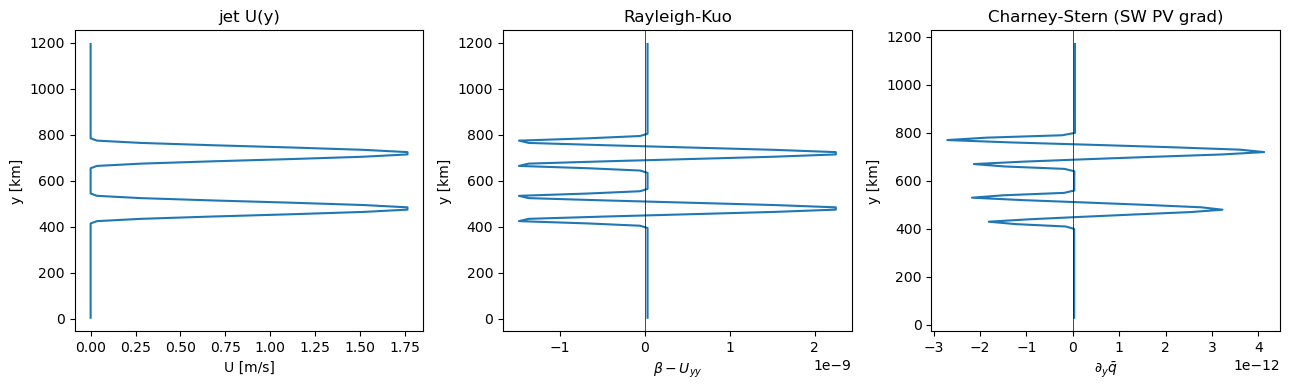

In [4]:
# Barotropic-instability criterion (Rayleigh-Kuo / Charney-Stern): a NECESSARY
# condition for instability is that the background potential-vorticity gradient
# changes sign in the interior. Evaluated on the initial balanced jet.
# See https://en.wikipedia.org/wiki/Rayleigh%E2%80%93Kuo_criterion

U   = M.u[0].mean(axis=1)                          # U(y)
Uyy = np.gradient(np.gradient(U, M.yh1), M.yh1)
RK  = M.beta - Uyy                                 # Rayleigh-Kuo (non-divergent barotropic)
dqdy = np.gradient(M.q(k=0).mean(axis=1), M.yq1)   # Charney-Stern: d/dy of zonal-mean SW PV
dqdy[:3] = np.nan                                  # mask near-wall rows where h->0 makes
dqdy[-2:] = np.nan                                 # q=(f+zeta)/h spike and swamp the interior

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].plot(U, M.yh1/1e3);    ax[0].set_xlabel('U [m/s]'); ax[0].set_ylabel('y [km]'); ax[0].set_title('jet U(y)')
ax[1].plot(RK, M.yh1/1e3);   ax[1].axvline(0, color='k', lw=0.5); ax[1].set_xlabel(r'$\beta - U_{yy}$'); ax[1].set_ylabel('y [km]'); ax[1].set_title('Rayleigh-Kuo')
ax[2].plot(dqdy, M.yq1/1e3); ax[2].axvline(0, color='k', lw=0.5); ax[2].set_xlabel(r'$\partial_y \bar{q}$'); ax[2].set_ylabel('y [km]'); ax[2].set_title('Charney-Stern (SW PV grad)')
fig.tight_layout()
# With the near-wall spike masked, the interior sign change in the SW PV gradient is
# visible in the Charney-Stern panel; the Rayleigh-Kuo panel is the cleaner read.

jj = (M.yh1/M.Ly > 0.12) & (M.yh1/M.Ly < 0.88)     # interior (skip dry walls)
print('Rayleigh-Kuo (beta - U_yy) changes sign in interior:', bool((RK[jj].min() < 0) and (RK[jj].max() > 0)))

# Control Run, Generate Input   

Run the Control run here to generate training input data. Need three columns including the open boundary column for training. 

To provide more training input, multiple columns are picked as open boundary. Each correspond to its own input data. All data are generated through one run. 

In [5]:
b_obc      = M.ni - 1 - 20                                 
ext_cols   = np.array([b_obc + 1, b_obc + 2])               
obc_gap    = 4                                             
n_obc      = 5                                              
b_obc_list = b_obc - obc_gap * np.arange(n_obc)[::-1]      
stencil_cols = np.unique(np.concatenate([(b - 2, b - 1, b) for b in b_obc_list])) 
probe_hi   = int(b_obc)                                     
probe_lo   = int(b_obc_list.min()) - 2                     
band_w     = probe_hi - probe_lo + 1                      
icol       = lambda c: int(c) - probe_lo                    
assert probe_lo <= int(b_obc_list.min()) - 2 and probe_hi >= int(b_obc_list.max()), 'probe band must cover every {b-2,b-1,b}'  # [OBC-SPACED]

SPONGE_BUFFER = 50e3                                        
dist_wall     = np.minimum(M.yh1, M.Ly - M.yh1)            
sponge_row    = M.h_relax[0, :, int(b_obc)] > 0          
sponge_reach  = float(dist_wall[sponge_row].max())         
row_keep      = dist_wall > (sponge_reach + SPONGE_BUFFER) 

print(f'[NN-DATA] probe band i = {probe_lo}..{probe_hi} ({band_w} cols);  '
      f'{len(b_obc_list)} OBC locations i = {list(b_obc_list)}  '
      f'(x = {np.round(M.xh1[b_obc_list]/1e3,0)} km)')

pres_cols = np.concatenate([west_cols])
ic = (M.u.copy(), M.v.copy(), M.h.copy(), M.time, M.iter)

u, v, h, time, h_bc_all, u_bc_all, v_bc_all, probe_band = M.run_record_bc(
    *run_params, pres_cols,
    store_downstream=True, probe_i0=probe_lo, n_probe=band_w)   


# Generate the 
tri_sl = slice(band_w - 3, band_w)              # [NN-DATA] last 3 band cols = [b_obc-2, b_obc-1, b_obc] (view, no copy)
probe = {'cols': np.array([b_obc - 2, b_obc - 1, b_obc]),
         'x_km': M.xh1[b_obc - 2:b_obc + 1] / 1e3,
         'h': probe_band['h'][..., tri_sl],
         'u': probe_band['u'][..., tri_sl],
         'v': probe_band['v'][..., tri_sl]}

# These are the columns for external forcing (at time step n + 1, probe stored after numerical scheme update)
h_ext_all = probe['h'][:, :, :, 2]
v_ext_all = probe['v'][:, :, :, 2]
u_ext_all = probe['u'][:, :, :, 2]

[NN-DATA] probe band i = 81..99 (19 cols);  5 OBC locations i = [np.int64(83), np.int64(87), np.int64(91), np.int64(95), np.int64(99)]  (x = [835. 875. 915. 955. 995.] km)
numba threads = 16
CFL: dt*f = 0.013569999999999999
CFL: dt*cg/dx = 0.08
CFL: dt*nu_h/dx^2 = 0.0002
CFL*: dt*epsilon/h_bot = 3.125e-06
CFL*: dt*nu_v/h_min^2 = 0.0
CFL*: dt*h_relax = 0.001
CFL*: dt*u_relax = 0.001
CFL*: dt*v_relax = 0.001
nsteps = 100000
Time: Trun * fo = 1000.0
Time: Trun * ( cg / L ) = 66.66666666666667
[OBC] recording (u,v,h) at boundary columns i = [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]
[OBC] also storing downstream probe at columns i = 81..99
Running (record)...
...done


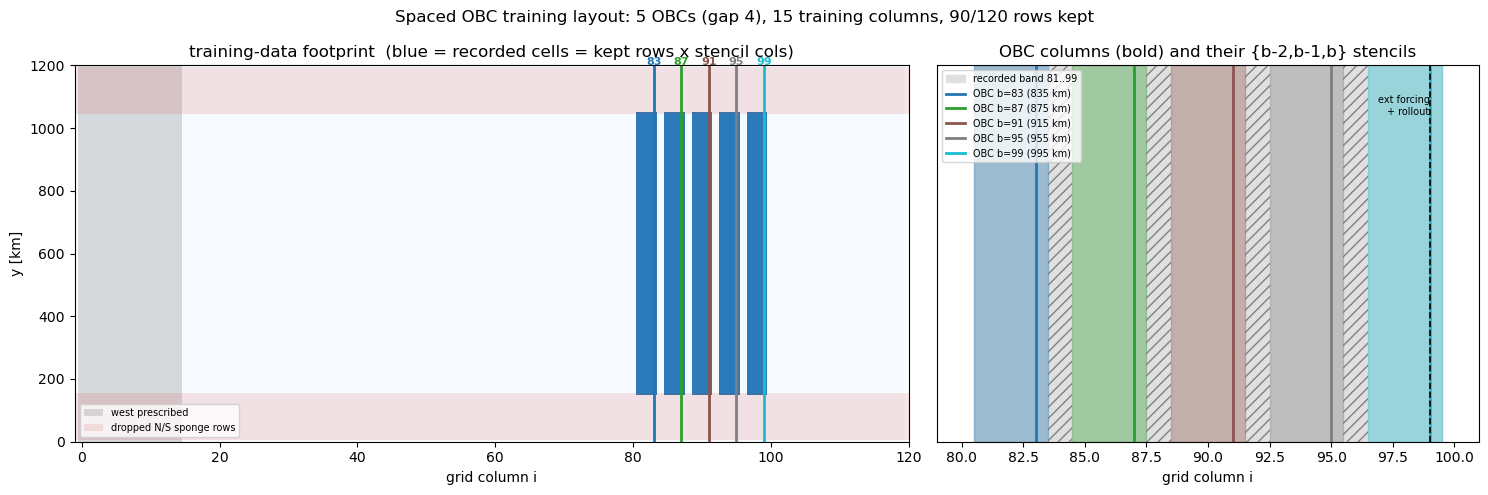

In [6]:
gap_cols   = np.array(sorted(set(range(probe_lo, probe_hi + 1)) - set(int(c) for c in stencil_cols)))  
y_km       = M.yh1 / 1e3                                   
obc_colors = plt.cm.tab10(np.linspace(0, 1, len(b_obc_list)))  
kept_rows  = np.where(row_keep)[0]; jlo, jhi = int(kept_rows.min()), int(kept_rows.max())  

figc, axc = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [2.0, 1.3]})  

train_mask = np.zeros((M.nj, M.ni), bool)               
train_mask[np.ix_(kept_rows, stencil_cols)] = True      
axc[0].pcolormesh(np.arange(M.ni), y_km, train_mask, cmap='Blues', vmin=0, vmax=1.4, shading='auto')
axc[0].axvspan(int(west_cols.min()) - .5, int(west_cols.max()) + .5, color='0.55', alpha=0.30, lw=0, label='west prescribed')
axc[0].axhspan(y_km[0],   y_km[jlo], color='C3', alpha=0.12, lw=0, label='dropped N/S sponge rows')
axc[0].axhspan(y_km[jhi], y_km[-1],  color='C3', alpha=0.12, lw=0)                                  
for col, b in zip(obc_colors, b_obc_list):               
    axc[0].axvline(int(b), color=col, lw=2)
    axc[0].text(int(b), y_km.max(), f'{int(b)}', color=col, ha='center', va='bottom', fontsize=8, fontweight='bold')
axc[0].set_xlim(-1, M.ni); axc[0].set_xlabel('grid column i'); axc[0].set_ylabel('y [km]')
axc[0].set_title('training-data footprint  (blue = recorded cells = kept rows x stencil cols)')
axc[0].legend(loc='lower left', fontsize=7)             

# [OBC-MAP] (right) column schematic: each OBC (bold line) and the 3 columns {b-2,b-1,b} that train it
axc[1].axvspan(probe_lo - .5, probe_hi + .5, color='0.88', label=f'recorded band {probe_lo}..{probe_hi}')
for col, b in zip(obc_colors, b_obc_list):              
    axc[1].axvspan(int(b) - 2.5, int(b) + .5, color=col, alpha=0.35)
    axc[1].axvline(int(b), color=col, lw=2, label=f'OBC b={int(b)} ({M.xh1[int(b)]/1e3:.0f} km)')
for g in gap_cols:                                      
    axc[1].axvspan(int(g) - .5, int(g) + .5, facecolor='none', edgecolor='0.5', hatch='///', lw=0)
axc[1].axvline(int(b_obc), color='k', ls='--', lw=1.2)  
axc[1].text(int(b_obc), 0.92, 'ext forcing\n+ rollout', fontsize=7, ha='right', va='top')
axc[1].set_xlim(probe_lo - 2, probe_hi + 2); axc[1].set_yticks([])
axc[1].set_xlabel('grid column i'); axc[1].set_title('OBC columns (bold) and their {b-2,b-1,b} stencils')
axc[1].legend(loc='upper left', fontsize=7)             
figc.suptitle(f'Spaced OBC training layout: {len(b_obc_list)} OBCs (gap {obc_gap}), '
              f'{len(stencil_cols)} training columns, {int(row_keep.sum())}/{M.nj} rows kept')
figc.tight_layout()                                     

# Pack and Normalization

Generate the training input. 

For each open boundary points, in total of 8 stencil value are needed to update it. 

| idx | grid point | time | notes |
| :---: | :---: | :---: | :--- |
| 0 | (b-1, j-1) | n | |
| 1 | (b-1, j) | n | |
| 2 | (b-1, j+1) | n | |
| 3 | (b, j-1) | n | |
| 4 | (b, j) | n | phi_prev_b (update law) |
| 5 | (b, j+1) | n | |
| 6 | (b-1, j) | n+1 | pim1 (update law) |
| 7 | (b-2, j) | n+1 | pim2 (network only) |

Here j is periodic. 

# Notes about Time Sequence
Since by defualt `phi_prob` stores value at time n+1 at time n. For example, `probe[0]` is the value at time step `1` and it is used for `iter=1` which si when updating the initial condition. So exactly matching `probe[i]` is the value at `i+1` time step. 



In [7]:
# Pack the Data
FIELDS     = ('h', 'u', 'v')
field_code = {'h': 0, 'u': 1, 'v': 2}

# Sample only 1 steps every 'stride' time step, reduce the training input size.
stride = 50
# Total number of time steps
nstep  = probe_band['h'].shape[0]

n0     = np.arange(0, nstep - 1, stride)        # step n  (partner n+1 = n0+1, the consecutive step)
jm = lambda A: np.roll(A,  1, axis=-1)          # (.., j-1)   (matches jm = j-1 in the scheme)
jp = lambda A: np.roll(A, -1, axis=-1)          # (.., j+1)

# P is the field, b is the obc location
def _pack(P, b):
    """P: band probe field (nstep,nk,nj,band_w) -> (X_raw (Ns,8), label (Ns,))."""
    Pb, Pbm1, Pbm2 = P[..., icol(b)], P[..., icol(b - 1)], P[..., icol(b - 2)]   # (nstep,nk,nj)
    Pb_n,  Pbm1_n            = Pb[n0],   Pbm1[n0]                                # step n
    Pb_n1, Pbm1_n1, Pbm2_n1 = Pb[n0+1], Pbm1[n0+1], Pbm2[n0+1]                   # step n+1 also for external forcing
    feats = np.stack([jm(Pbm1_n), Pbm1_n, jp(Pbm1_n),     # 0,1,2 : (b-1, j-1/j/j+1) @ n
                      jm(Pb_n),   Pb_n,   jp(Pb_n),       # 3,4,5 : (b,   j-1/j/j+1) @ n
                      Pbm1_n1, Pbm2_n1], axis=-1)         # 6,7   : pim1, pim2 @ n+1
    return feats.reshape(-1, 8), Pb_n1.reshape(-1)


# See Explaination in the following cell. 
Xr, yy, fid, lid, bid, rid = [], [], [], [], [], []   # [OBC-SPONGE] rid tracks the j-row per sample
lay_tile = np.tile(np.repeat(np.arange(M.nk), M.nj), len(n0))   # layer index per flattened (n,k,j)
row_tile = np.tile(np.arange(M.nj), len(n0) * M.nk)            # [OBC-SPONGE] j-row per flattened (n,k,j) -- j is the innermost (fastest) axis
for b in b_obc_list:
    for fn in FIELDS:
        Xb, yb = _pack(probe_band[fn], int(b))
        Xr.append(Xb); yy.append(yb)
        fid.append(np.full(yb.shape, field_code[fn], np.int64))
        lid.append(lay_tile.copy())
        bid.append(np.full(yb.shape, int(b), np.int64))
        rid.append(row_tile.copy())                            # [OBC-SPONGE] same (n,k,j) order as feats.reshape(-1,8)

In [ ]:
X_raw    = np.concatenate(Xr).astype(np.float32)   # (N,8) raw physical stencil (feeds the update law)
y        = np.concatenate(yy).astype(np.float32)   # (N,)  boundary-column value @ n+1 (control)
field_id = np.concatenate(fid)                     # (N,) 0/1/2 = h/u/v
layer_id = np.concatenate(lid)                     # (N,) layer k
loc_id   = np.concatenate(bid)                     # (N,) OBC column b (provenance / train-val split)
row_id   = np.concatenate(rid)                     
N_full   = X_raw.shape[0]

# [OBC-SPONGE] Drop training samples inside the N/S sponge
keep         = row_keep[row_id]                              
X_raw, y           = X_raw[keep], y[keep]                   
field_id, layer_id = field_id[keep], layer_id[keep]         
loc_id, row_id     = loc_id[keep], row_id[keep]             
phi_ext  = y.copy()                                          
_kj = np.where(row_keep)[0]

print(f'[OBC-SPONGE] sponge_reach={sponge_reach/1e3:.0f} km + buffer {SPONGE_BUFFER/1e3:.0f} km '
      f'-> keep rows j{_kj.min()}..{_kj.max()} (y {M.yh1[_kj.min()]/1e3:.0f}..{M.yh1[_kj.max()]/1e3:.0f} km), '
      f'{int(row_keep.sum())}/{M.nj} rows')
print(f'[NN-DATA] packed {X_raw.shape[0]:,} samples (was {N_full:,}; dropped {N_full - X_raw.shape[0]:,} sponge rows)  '
      f'({len(b_obc_list)} loc x {len(FIELDS)} fields x {len(n0)} step-pairs x {M.nk*int(row_keep.sum())} pts)')

[OBC-SPONGE] sponge_reach=95 km + buffer 50 km -> keep rows j15..104 (y 155..1045 km), 90/120 rows
[NN-DATA] packed 2,700,000 samples (was 3,600,000; dropped 900,000 sponge rows)  (5 loc x 3 fields x 2000 step-pairs x 90 pts)


# Normalization

Two methods of normalization are implemented

1. Robust : Use the difference between 75 quaentils and 25 quaentiles as the sclae
2. Min-max : Use difference between max and min as scale. 

If the sample happens to be constant, both scales generate a scale of 0, which is unrealistic, in this case just assign the scale to be 1.0. (Question about this patr)

We do a per-sample normalization because the phase velocity $c_x, c_y$ are dimensionless. So it doesn't matter that different sample uses different scale. 

In [10]:
# 0 = robust (median/IQR), 1 = min-max -- applied PER SAMPLE
norm_mode = 1        

# ---- per-sample stats over the 8 stencil values (axis=1) ----
if norm_mode == 1:
    center_s = X_raw.min(axis=1, keepdims=True)               
    scale_s  = X_raw.max(axis=1, keepdims=True) - center_s   # [NN-DATA] FIX: was `- min` (undefined builtin); min-max range = max - center
else:
    center_s = np.median(X_raw, axis=1, keepdims=True)         # (N,1) per-sample median
    quas       = np.percentile(X_raw, [75, 25], axis=1)          # (2,N)
    scale_s  = (quas[0] - quas[1])[:, None]                         # (N,1) per-sample IQR

scale_s = np.where(scale_s <= 0, 1.0, scale_s).astype(np.float32)   # guard constant samples
X_norm  = ((X_raw - center_s) / scale_s).astype(np.float32)         # (N,8) per-sample normalized
sample_scale = scale_s[:, 0]                                        # (N,) per-sample scale (for the plot)

# ---- per-VARIABLE GLOBAL scale (for the LOSS field-weight 1/glob_scale, NOT input norm) ----
def _global_scale(v):                                          # v: all pooled values of one field
    if norm_mode == 1:
        rng = float(np.max(v) - np.min(v)); return rng if rng > 0 else 1.0
    iqr = float(np.subtract(*np.percentile(v, [75, 25]))); return iqr if iqr > 0 else (float(np.std(v)) or 1.0)
glob_scale = np.array([_global_scale(X_raw[field_id == c]) for c in (0, 1, 2)], np.float32)
print(f"[NN-DATA] per-sample normalization ({'min-max' if norm_mode == 1 else 'robust'});  "
      f"per-variable global scale = {np.round(glob_scale, 4)}")

# network input = [ 8 normalized values | field one-hot(3) | layer ]
field_oh = np.eye(3, dtype=np.float32)[field_id]
X_net    = np.concatenate([X_norm, field_oh, layer_id.astype(np.float32)[:, None]], axis=1)  # (N,12)
print(f'[NN-DATA] X_net {X_net.shape} | X_raw {X_raw.shape} | y {y.shape}')

np.savez_compressed('nn_obc_training_data.npz',
    X_net=X_net, X_raw=X_raw, y=y, phi_ext=phi_ext,
    field_id=field_id, layer_id=layer_id, loc_id=loc_id,
    norm_mode=norm_mode, glob_scale=glob_scale)
print('[NN-DATA] saved -> nn_obc_training_data.npz')

[NN-DATA] per-sample normalization (min-max);  per-variable global scale = [426.2946   2.8907   2.031 ]
[NN-DATA] X_net (2700000, 12) | X_raw (2700000, 8) | y (2700000,)
[NN-DATA] saved -> nn_obc_training_data.npz


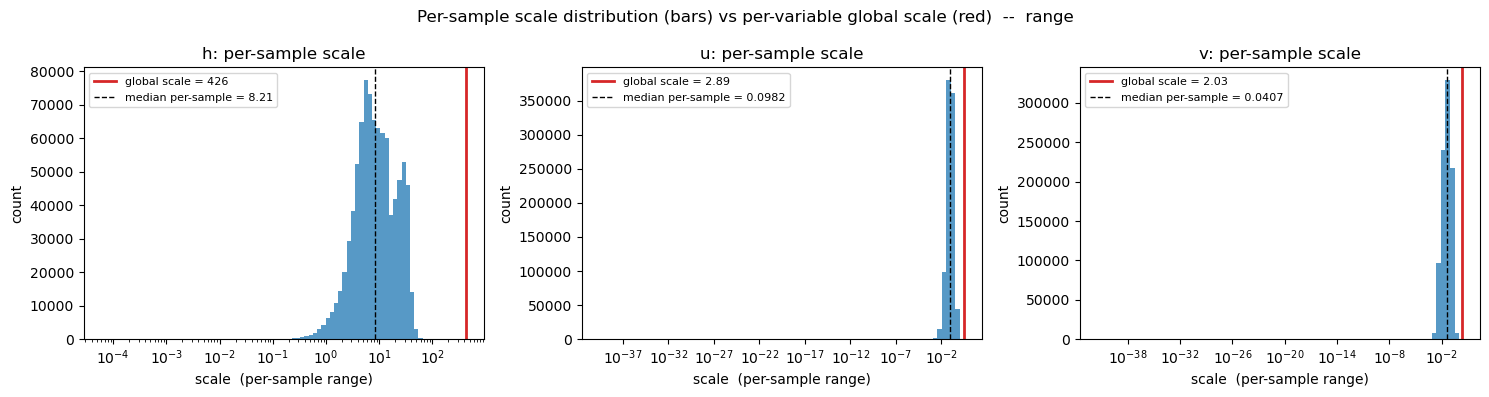

In [11]:
# [NN-DATA] Compare the PER-SAMPLE scale (one per sample, bars) against the single
# PER-VARIABLE GLOBAL scale (red line). If per-sample scales span orders of magnitude,
# the global scale cannot represent all samples -- that is the motivation for per-sample.
scale_kind = 'range' if norm_mode == 1 else 'IQR'
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for c, fn in enumerate(FIELDS):
    s = sample_scale[field_id == c]
    s = s[s > 0]                                              # drop guarded (constant) samples
    bins = np.logspace(np.log10(s.min()), np.log10(s.max()), 80)
    ax[c].hist(s, bins=bins, color='C0', alpha=0.75)
    ax[c].axvline(glob_scale[c], color='C3', lw=2, label=f'global scale = {glob_scale[c]:.3g}')
    ax[c].axvline(np.median(s),  color='k', ls='--', lw=1, label=f'median per-sample = {np.median(s):.3g}')
    ax[c].set_xscale('log')
    ax[c].set_title(f'{fn}: per-sample scale')
    ax[c].set_xlabel(f'scale  (per-sample {scale_kind})'); ax[c].set_ylabel('count'); ax[c].legend(fontsize=8)
fig.suptitle(f'Per-sample scale distribution (bars) vs per-variable global scale (red)  --  {scale_kind}')
fig.tight_layout()

# Neural Network Artitecture

The network **replaces the analytic phase-speed estimate** `(cx, cy)` of the east-Orlanski
scheme. Everything physical — the radiation update and the inflow nudge — stays in the
differentiable helper `orlanski_east_update`. The net never sees `alpha_in` and does **not**
decide inflow/outflow.


- **Input** `X_net` (12) = 8 per-sample-normalized stencil values + field one-hot(3) + layer.
  The raw physical `X_raw` is **not** fed to the net — it feeds the update law (physical units). 
  1. The one-hot here is a index for different variable. This is letting the Neural Network knows which variable it is working on. 
- **Architecture**: one shared MLP `12 → 32 → 32 → 2` (ReLU). Shared across h/u/v; the field
  one-hot lets it specialize without training three separate nets.
- **Outputs**: `cx = sigmoid(·) ∈ [0,1]` (keeps the `1/(1+cx)` denominator stable) and
  `cy = tanh(·) ∈ [-1,1]`. These differentiable squashes replace the analytic hard clamps so
  gradients survive at the rails.
- **inflow / outflow** is decided analytically by `orlanski_east_analytic` (the `rx<0` test),
  not by the net. On **outflow** the net's `(cx, cy)` radiate; on **inflow** the fixed
  `alpha_in` nudge is applied (no `cx, cy`). Its residual is included in the loss but carries no gradients because the Nudging doesn't involve $c_x$ or $c_y$. 
- **Loss** (Option A): `mean[ ((phi_b_pred − y)/glob_scale[field])² ]` over all points,
  per-field weighted so h (~100 m) and u, v (~0.1) contribute comparably.

  The total parameter currently is 

  $$ 12 \times 32 + 32 \times 32 + 32 \times 2 = 1538 $$

In [12]:
torch.manual_seed(0)
# [NN-MODEL] use the GPU when a CUDA build of torch sees it; else fall back to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '|',
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU (torch built WITHOUT CUDA)')


class OBCNet(nn.Module):
    """Predict (cx, cy) from X_net (..., 12) = [8 normalized stencil | field one-hot(3) | layer].
    cx = sigmoid -> [0,1] (keeps 1/(1+cx) stable);  cy = tanh -> [-1,1].
    The net does NOT decide inflow/outflow and never sees alpha_in -- those live in the helper.
    """

    def __init__(self, n_in=12, hidden=(32, 32)):
        super().__init__()
        layers, d = [], n_in
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU()]
            d = h
        self.body = nn.Sequential(*layers)
        self.head = nn.Linear(d, 2)                     # -> (cx_raw, cy_raw)

    # Output layer, produce two raw number (unbounded)
    def forward(self, x):
        z  = self.head(self.body(x))
        cx = torch.sigmoid(z[..., 0])                   # [0,1]
        cy = torch.tanh(z[..., 1])                      # [-1,1]
        return cx, cy


net = OBCNet().to(device)
print(net)
print('trainable params:', sum(p.numel() for p in net.parameters()))

# sanity check on a small batch from the packed data (X_net built in the normalization cell)
xb = torch.as_tensor(X_net[:4], dtype=torch.float32, device=device)
cx, cy = net(xb)
print('cx', tuple(cx.shape), cx.min().item(), cx.max().item(),
      '| cy', tuple(cy.shape), cy.min().item(), cy.max().item())

device: cuda | NVIDIA GeForce RTX 4060 Laptop GPU
OBCNet(
  (body): Sequential(
    (0): Linear(in_features=12, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
  )
  (head): Linear(in_features=32, out_features=2, bias=True)
)
trainable params: 1538
cx (4,) 0.4942352771759033 0.4942352771759033 | cy (4,) 0.06294762343168259 0.06294762343168259


# Loss function

**Option A** — the loss is the per-field-weighted boundary MSE over **all** points
(inflow + outflow):

$$\mathcal{L} = \frac{1}{N}\sum_i \left(\frac{\hat\phi_{b,i} - y_i}{\text{glob\_scale}[\text{field}_i]}\right)^2,
$$
where

$$ \hat\phi_b = \texttt{orlanski\_east\_update}(X_{\text{raw}}, c_x, c_y, \text{inflow}, \phi_{\text{ext}}, \alpha_{\text{in}})
$$
- `(cx, cy)` come from the net; they drive the **outflow** radiation.
- **inflow** points use the fixed `ALPHA_IN` nudge (no `cx, cy`) — they contribute to the
  loss value but carry **zero gradient** to the net. We therefore also report `loss_outflow` / `loss_inflow` separately:
  `loss_outflow` tracks learning; `loss_inflow` should be flat.
- Per-field weight `1/glob_scale` puts h (~100 m) and u, v (~0.1) on comparable footing.
- The **analytic baseline** (same update, analytic `cx, cy`) is the number to beat — and
  since both share the inflow nudge, the real comparison is on `outflow`.

In [ ]:
# Input for the NN
X_net_t   = torch.as_tensor(X_net,   dtype=torch.float32, device=device)  
# Raw data for update law (orlanski_east_update)
X_raw_t   = torch.as_tensor(X_raw,   dtype=torch.float32, device=device)  
# Boundary value from control run (truth)
y_t       = torch.as_tensor(y,       dtype=torch.float32, device=device)   
# External Force for Nudging
phi_ext_t = torch.as_tensor(phi_ext, dtype=torch.float32, device=device) 
# Field code
fid_t     = torch.as_tensor(field_id, dtype=torch.long,   device=device)   
w_field   = torch.as_tensor(1.0 / glob_scale, dtype=torch.float32, device=device)  
w_t       = w_field[fid_t]                                                 

# Inflow mask
with torch.no_grad():
    # Here inflow_t is a (N,) boolean, True for inflow. 
    _, _, inflow_t = orlanski_east_analytic(X_raw_t)                        
print(f'[NN-LOSS] inflow fraction = {inflow_t.float().mean().item():.3f}  (rest outflow)')

ALPHA_IN = 0.99  # Inflow Nudging Coefficient

def obc_loss(net, idx):
    """Option-A loss on the samples `idx` (a LongTensor of indices): per-field-weighted
    boundary MSE over ALL points (inflow + outflow). The net's (cx, cy) drive OUTFLOW
    radiation; INFLOW uses the fixed ALPHA_IN nudge (no cx, cy). Returns
    (loss, loss_outflow, loss_inflow) -- train on `loss`, watch the other two."""
    cx, cy = net(X_net_t[idx])                                             # network phase speed
    phi = orlanski_east_update(X_raw_t[idx], cx, cy,
                               inflow=inflow_t[idx], phi_ext=phi_ext_t[idx],
                               alpha_in=ALPHA_IN)                          # phi_b_pred (physical units)
    sq = (w_t[idx] * (phi - y_t[idx])) ** 2                                # per-field-weighted squared residual
    inflow = inflow_t[idx]
    loss     = sq.mean()                                                 
    loss_out = sq[~inflow].mean() if (~inflow).any() else loss.new_zeros(())
    loss_in  = sq[inflow ].mean() if   inflow.any()  else loss.new_zeros(())
    return loss, loss_out, loss_in


# [NN-LOSS] analytic baseline = the loss to beat: same update + same ALPHA_IN, but (cx, cy)
# from the analytic Orlanski estimate. Inflow residual is identical to the net's (both nudge),
# so the network can only win on OUTFLOW -> watch `outflow` for the real comparison.
with torch.no_grad():
    cx_a, cy_a, _ = orlanski_east_analytic(X_raw_t)
    phi_a = orlanski_east_update(X_raw_t, cx_a, cy_a,
                                 inflow=inflow_t, phi_ext=phi_ext_t, alpha_in=ALPHA_IN)
    sq_a = (w_t * (phi_a - y_t)) ** 2
    base_all = sq_a.mean().item()
    base_out = sq_a[~inflow_t].mean().item()
    base_in  = sq_a[inflow_t].mean().item()
print(f'[NN-LOSS] analytic baseline loss:  all={base_all:.4e}  outflow={base_out:.4e}  inflow={base_in:.4e}')

[NN-LOSS] inflow fraction = 0.337  (rest outflow)
[NN-LOSS] analytic baseline loss:  all=1.3495e-07  outflow=2.0362e-07  inflow=1.8049e-11


# Training

Teacher-forcing training of `OBCNet` on the packed samples.


- **Main** minimize the per-field-weighted boundary MSE `obc_loss`.
- `Adam`, full-batch-shuffled minibatches on the GPU. Saves `obc_net.pth`.

In [ ]:
# Split to Training and Validataion
# Location for validation
val_locs = torch.tensor([87, 95], device=device)                
loc_t    = torch.as_tensor(loc_id, device=device)
val_mask = torch.isin(loc_t, val_locs)
tr_idx   = torch.where(~val_mask)[0]                             
val_idx  = torch.where( val_mask)[0]
assert len(tr_idx) > 0 and len(val_idx) > 0, 'empty train/val split -- check val_locs vs loc_id'
print(f'[NN-TRAIN] train {len(tr_idx):,}  val {len(val_idx):,}  (val locs {val_locs.tolist()})')

[NN-TRAIN] train 1,620,000  val 1,080,000  (val locs [87, 95])


## Optimizer

Use `Adam` with learning rate `learning_rate`

### Some Explaination here

`perm` is passed through the function `randperm` for shuffling. Since I don't want to input something that is ordered chronologically

`hist = {'tr': [], 'val': [], 'val_out': []}` record the three curvevs across epochs : 
- `tr` : Training loss
- `val` : Validation total loss
- `val_out` validation outflow loss

Loss for inflow and outflow are also stored but only the `Loss` is involved in model training. 



In [ ]:
# Optimizer
learning_rate = 3e-3
opt   = torch.optim.Adam(net.parameters(), lr = learning_rate)
BATCH = 65536
EPOCHS = 200

def train_model(network, loss_fn, idx, optimizer, batch_size):
    network.train()
    perm = idx[torch.randperm(len(idx), device = idx.device)]
    total = 0.0
    # The main training loop. Iterated over the shuffled indices in chunks of batch_size. 
    for s in range(0, len(perm), batch_size):
        loss, _, _ = loss_fn(network, perm[s:s + batch_size])
        # Clear the Gradient
        optimizer.zero_grad()

        # Back Propagation
        loss.backward()
        optimizer.step()

        total += loss.item()    

    # Number of Batches                         
    n_batches = (len(perm) + batch_size - 1) // batch_size 
    # Return the mean loss per batch
    return total / n_batches                              

def test_model(network, loss_fn, idx):
    " Evaluate on the Validation indiced, the network is untouched."
    network.eval()
    with torch.no_grad():
        loss, loss_out, loss_in = loss_fn(network, idx)
    return loss.item(), loss_out.item(), loss_in.item()

def fit_model(network, loss_fn, optimizer, tr_idx, val_idx, n_epochs, batch_size):
    import time as _time   
                                   
    hist = {'tr': [], 'val': [], 'val_out': []}
    t0 = _time.time()                                    
    # Iterate through epochs, each step perform the train_model function from above. 
    for ep in range(1, n_epochs + 1):
        tr = train_model(network, loss_fn, tr_idx, optimizer, batch_size)
        val, val_out, _ = test_model(network, loss_fn, val_idx)
        hist["tr"].append(tr); hist["val"].append(val); hist["val_out"].append(val_out)
    print(f"Training completed in {int(_time.time() - t0)} s.")
    return hist

## Train the Network

All the components are ready and below train the model

Training completed in 36 s.
final val_out / analytic_out = 0.392
[NN-TRAIN] saved -> obc_net.pth  (state_dict + norm_mode + glob_scale)


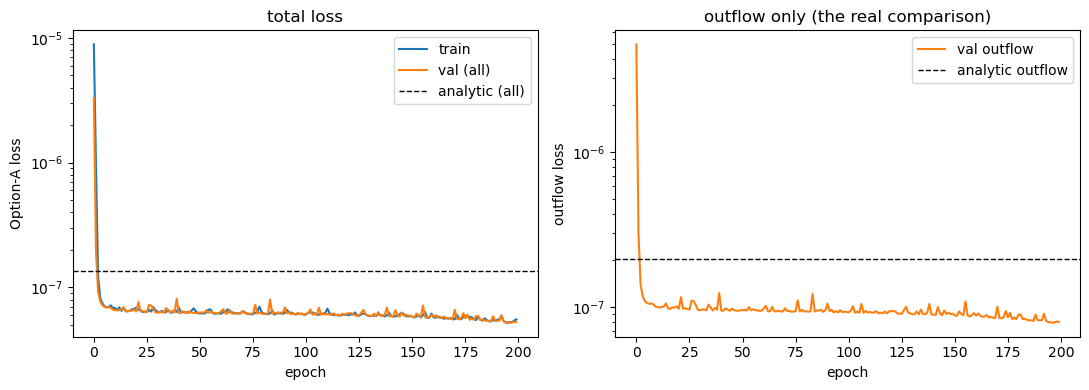

In [16]:
torch.manual_seed(0)
hist = fit_model(net, obc_loss, opt, tr_idx, val_idx, n_epochs=EPOCHS, batch_size=BATCH)
print(f"final val_out / analytic_out = {hist['val_out'][-1] / base_out:.3f}")


# ---- loss curves ----
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogy(hist['tr'], label='train'); ax[0].semilogy(hist['val'], label='val (all)')
ax[0].axhline(base_all, color='k', ls='--', lw=1, label='analytic (all)')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('Option-A loss'); ax[0].set_title('total loss'); ax[0].legend()
ax[1].semilogy(hist['val_out'], color='C1', label='val outflow')
ax[1].axhline(base_out, color='k', ls='--', lw=1, label='analytic outflow')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('outflow loss'); ax[1].set_title('outflow only (the real comparison)'); ax[1].legend()
fig.tight_layout()

# [NN-TRAIN] save as a DICT so the run cell can read norm_mode (its loader also accepts a bare state_dict)
torch.save({'state_dict': net.state_dict(), 'norm_mode': int(norm_mode), 'glob_scale': glob_scale}, 'obc_net.pth')
print('[NN-TRAIN] saved -> obc_net.pth  (state_dict + norm_mode + glob_scale)')

[CX-DIAG] outflow c_x: net collapses to ~const ~0 (corr~0, much smaller spread than analytic)
  h: corr(cx)=+0.007  mean cx_nn=0.014 vs cx_a=0.003  | strong: cx_a=0.047 -> cx_nn=0.013 (28% kept)
  u: corr(cx)=-0.010  mean cx_nn=0.012 vs cx_a=0.004  | strong: cx_a=0.068 -> cx_nn=0.012 (17% kept)
  v: corr(cx)=-0.015  mean cx_nn=0.005 vs cx_a=0.009  | strong: cx_a=0.132 -> cx_nn=0.005 (4% kept)


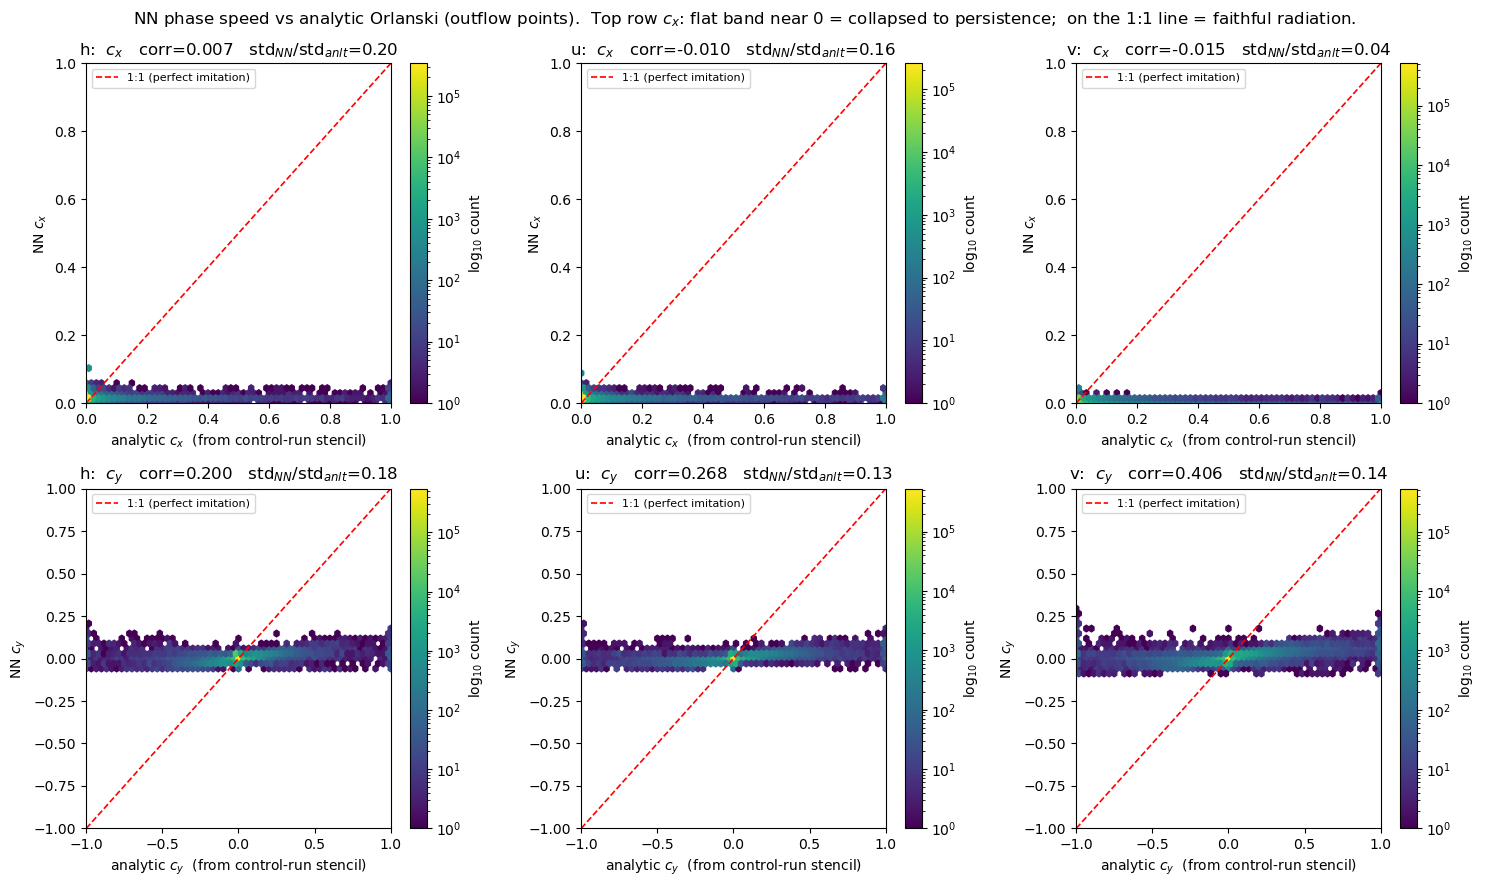

In [ ]:
# ===== NN phase speed (cx, cy) vs analytic Orlanski estimate =====

# packed training data
_dz   = np.load('nn_obc_training_data.npz') 
 
# net input | raw stencil | field code                               
_Xnet, _Xraw, _fid = _dz['X_net'], _dz['X_raw'], _dz['field_id']       
# the model the rollout uses    
_ck   = torch.load('obc_net.pth', map_location=device, weights_only=False)
_sd   = _ck['state_dict'] if (isinstance(_ck, dict) and 'state_dict' in _ck) else _ck  # wrapped or bare
_netp = OBCNet().to(device); _netp.load_state_dict(_sd); _netp.eval()       # fresh copy, don't touch `net`

with torch.no_grad():      
    # NN (cx,cy)                                                 
    _cx_nn, _cy_nn       = _netp(torch.as_tensor(_Xnet, dtype=torch.float32, device=device))       
    # analytic (cx,cy,inflow)
    _cx_a, _cy_a, _infl  = orlanski_east_analytic(torch.as_tensor(_Xraw, dtype=torch.float32))    

_cx_nn = _cx_nn.cpu().numpy(); _cy_nn = _cy_nn.cpu().numpy()                
_cx_a  = _cx_a.cpu().numpy();  _cy_a  = _cy_a.cpu().numpy()                 
_outflow = ~_infl.cpu().numpy()                                            # cx is meaningful only on outflow

_names = ['h', 'u', 'v']                                                    
fig, ax = plt.subplots(2, 3, figsize=(15, 9))                              
for _c in range(3):                                                       
    _m = _outflow & (_fid == _c)                                           
    for _r, (_cn, _ca, _lab, _lim) in enumerate([(_cx_nn, _cx_a, 'c_x', (0.0, 1.0)),    
                                                  (_cy_nn, _cy_a, 'c_y', (-1.0, 1.0))]): 
        _a  = ax[_r, _c]                                                   
        _hb = _a.hexbin(_ca[_m], _cn[_m], gridsize=60, bins='log', cmap='viridis',      
                        extent=(_lim[0], _lim[1], _lim[0], _lim[1]))       
        _a.plot(_lim, _lim, 'r--', lw=1.2, label='1:1 (perfect imitation)')
        _corr = np.corrcoef(_ca[_m], _cn[_m])[0, 1]                        
        _a.set_title(f'{_names[_c]}:  ${_lab}$   corr={_corr:.3f}   '       
                     f'std$_{{NN}}$/std$_{{anlt}}$={_cn[_m].std()/_ca[_m].std():.2f}')   
        _a.set_xlabel(f'analytic ${_lab}$  (from control-run stencil)')     
        _a.set_ylabel(f'NN ${_lab}$'); _a.set_xlim(_lim); _a.set_ylim(_lim) 
        _a.legend(loc='upper left', fontsize=8)                            
        fig.colorbar(_hb, ax=_a, label='log$_{10}$ count')                 
fig.suptitle('NN phase speed vs analytic Orlanski (outflow points).  Top row $c_x$: flat band near 0 '  
             '= collapsed to persistence;  on the 1:1 line = faithful radiation.', fontsize=12)         
fig.tight_layout()                                                                  

# Free-running rollout: classical 2D Orlanski (in-step) vs 2D Orlanski + Neural Network

Put the trained net **back into the model** and integrate, comparing it against the analytic scheme.

- **classical** — the **native in-step** 2D Orlanski OBC via `OSSWEM_obc_orlanski_2D.run_obc`, where the OBC is applied *inside* the `@njit` step (`obc_on=1`), so the updated boundary column feeds into the rest of that same step's interior dynamics.
- **neural** — the trained `OBCNet` via `run_obc_nn`, which must **lift the OBC out of the `@njit` step** (interior advanced with `obc_on=0`, then column `b` overwritten in numpy) because the torch net cannot run inside numba `nopython`. `nn_phase_fn` normalizes the raw stencil **exactly as in training** (per-sample min-max + field one-hot + layer).

Both runs share the same west prescription, sponge, IC, `b_obc`, and inflow nudging (`alpha_in=0.99`); inflow/outflow is decided analytically and the net supplies `(cx, cy)` for outflow only. We score each run by the **interior RMS error against the full-domain control** over columns `[0..b]` — a rising curve means the OBC is reflecting energy back inward, so *lower is better*.

> ⚠️ **Caveat:** the classical run is now **in-step** while the NN run is **out-of-step**, so their gap mixes *"analytic vs NN phase speed"* with *"in-step vs out-of-step OBC coupling"* (an O(dt) difference in when the boundary couples to the interior). To isolate purely the phase-speed source, compare against `run_obc_nn(phase_fn=None)` (out-of-step analytic) instead.

In [ ]:
# Reload the Setting of Control Run, Dulplicate here for Test Runs
def _fresh_model(cls):
    M2 = cls(M.ni, M.g, M.Ho, M.Lx, M.fo, M.beta, M.epsilon, M.nu_h,  # [FRESH-ROBUST] no hardcoded constants
             nu_v=M.nu_v, h_zonal_relax=M.h_zonal_relax, hsub=M.hsub,  # [FRESH-ROBUST]
             nj=M.nj, Ly=M.Ly)                                         # [FRESH-ROBUST] exact grid however M was built
    M2.u_target = M.u_target.copy(); M2.v_target = M.v_target.copy(); M2.h_target = M.h_target.copy()  # [FRESH-ROBUST] +v_target
    M2.D[:] = M.D                                                     # [FRESH-ROBUST] bathymetry (dry-row walls etc.) if any
    M2.u_relax  = M.u_relax.copy();  M2.v_relax  = M.v_relax.copy();  M2.h_relax = M.h_relax.copy()
    M2.u[:], M2.v[:], M2.h[:] = ic[0], ic[1], ic[2]
    M2.time, M2.iter = ic[3], ic[4]
    return M2

# Load the Trained Model

import importlib                                                         
import OSSWEM_obc_orlanski_2D_NN as _nnmod                               
import OSSWEM_obc_orlanski_2D    as _mod2d                              
importlib.reload(_nnmod); importlib.reload(_mod2d)                       
SSWEM_NN = _nnmod.SSWEM
SSWEM_2D = _mod2d.SSWEM                                                

# The Trained Neural Network
ckpt = torch.load('obc_net.pth', map_location=device, weights_only=False)
if isinstance(ckpt, dict) and 'state_dict' in ckpt:          # wrapped {'state_dict','norm_mode',...}
    state_dict = ckpt['state_dict']
    SAVED_NORM = int(ckpt.get('norm_mode', norm_mode))       # match training normalization
else:                                                        # bare state_dict -> no embedded norm info
    state_dict = ckpt
    SAVED_NORM = int(norm_mode)                              # fall back to the notebook's norm_mode
    print('[NN-OBC-RUN] WARNING: obc_net.pth is a bare state_dict (no norm_mode); '
          f'falling back to notebook norm_mode={SAVED_NORM}. Re-run training to embed it.')
net.load_state_dict(state_dict); net.eval()
print(f'[NN-OBC-RUN] loaded obc_net.pth; norm_mode={SAVED_NORM}  (device={device})')


[NN-OBC-RUN] loaded obc_net.pth; norm_mode=1  (device=cuda)
mesh: ni = 120  nj = 120
Grid: dx = 10000.0 [m]  dy = 10000.0 [m]
cg = 8.0 [m s-1]
Ld = 80000.0 [m]
Scales: Ls=epsilon/D/beta = 1041.6666666666667 [m]
Scales: Lx/Ld = 15.0
Res: Ld/dx = 8.0
Res: Ls/dx = 0.10416666666666667
numba threads = 16
CFL: dt*f = 0.013569999999999999
CFL: dt*cg/dx = 0.08
CFL: dt*nu_h/dx^2 = 0.0002
CFL*: dt*epsilon/h_bot = 3.125e-06
CFL*: dt*nu_v/h_min^2 = 0.0
CFL*: dt*h_relax = 0.001
CFL*: dt*u_relax = 0.001
CFL*: dt*v_relax = 0.001
nsteps = 100000
Time: Trun * fo = 1000.0
Time: Trun * ( cg / L ) = 66.66666666666667
[OBC - Orlanski - 2D - IndepRx] east r_x estimated independently per field (h, u, v)
[OBC - Orlanski - 2D - Nuding] east inflow scheme: NUDGING (alpha_in=0.99, ghost wall removed)
...done
Mean r_x over run is h = 0.006u=0.004  v=0.012
mesh: ni = 120  nj = 120
Grid: dx = 10000.0 [m]  dy = 10000.0 [m]
cg = 8.0 [m s-1]
Ld = 80000.0 [m]
Scales: Ls=epsilon/D/beta = 1041.6666666666667 [m]
Scales: L

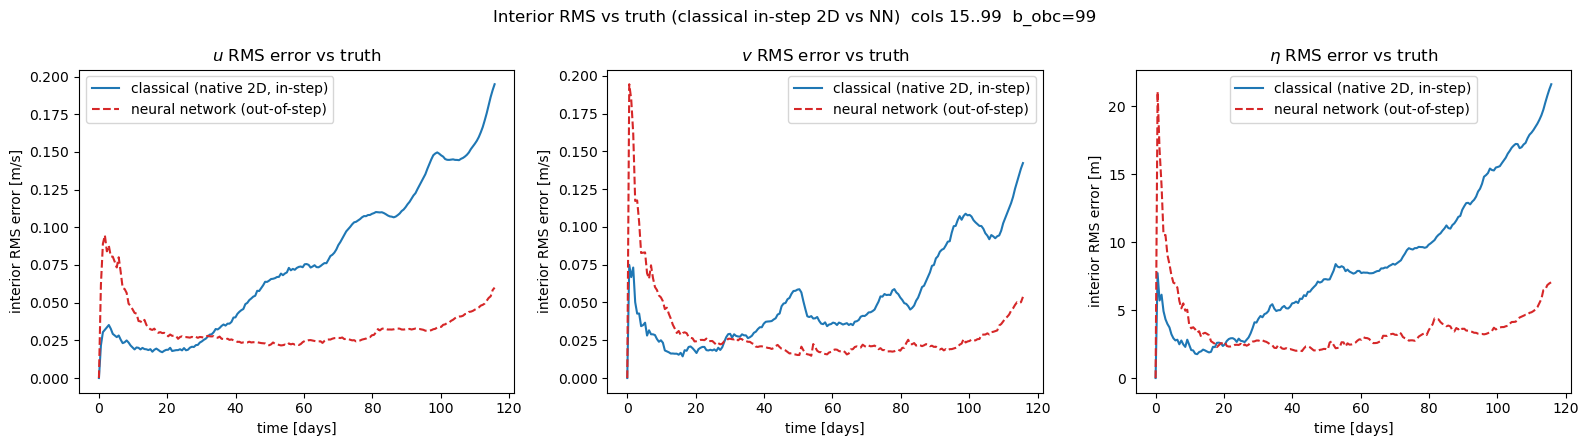

In [ ]:

# This Function is Necessary for Bridging the Simulation and the Neural Network. 
def nn_phase_fn(Xf, fc):
    """Xf: (m, 8) raw stencil batch.  fc: scalar field code 0/1/2.  Returns (cx, cy) numpy (m,)."""
    m = Xf.shape[0]
    # 1. Normalize the Input, to feed it into the Neural Network. 
    if SAVED_NORM == 1:  # min-max
        lo  = Xf.min(axis=1, keepdims=True)
        rng = Xf.max(axis=1, keepdims=True) - lo
        rng = np.where(rng <= 0, 1.0, rng)                  # guard constant samples
        Xn  = (Xf - lo) / rng
    else:                 # robust: median / IQR
        med = np.median(Xf, axis=1, keepdims=True)          
        qs  = np.percentile(Xf, [75, 25], axis=1)          
        iqr = np.where((qs[0] - qs[1]) <= 0, 1.0, qs[0] - qs[1])[:, None]   
        Xn  = (Xf - med) / iqr                             
    # Add the Identity Matrix (one-hot) + layer index. 
    oh = np.tile(np.eye(3, dtype=np.float32)[fc], (m, 1))   # scalar fc -> (m,3)
    X_net_np = np.concatenate([Xn, oh, np.zeros((m, 1))], axis=1).astype(np.float32)  

    # Networ forward, return the cx, cy from the Neural Network. 
    with torch.no_grad():
        cx, cy = net(torch.as_tensor(X_net_np, dtype=torch.float32, device=device))   
    return cx.cpu().numpy(), cy.cpu().numpy()

# Numerical 2D Orlanski Run : 
M_c = _fresh_model(SSWEM_2D)                                            
u_c, v_c, h_c, t_c, _, _ = M_c.run_obc(*run_params, pres_cols,             h_bc_all, u_bc_all, v_bc_all, b_obc,
    nudging=True, h_ext_all=h_ext_all, u_ext_all=u_ext_all, v_ext_all=v_ext_all,
    alpha_in=0.99)                                                      

# NN run: out-of-step driver run_obc_nn
M_n = _fresh_model(SSWEM_NN)                                            
u_n, v_n, h_n, t_n, _ = M_n.run_obc_nn(*run_params, pres_cols,
    h_bc_all, u_bc_all, v_bc_all, b_obc,
    h_ext_all, u_ext_all, v_ext_all,
    phase_fn=nn_phase_fn, nudging=True, alpha_in=0.99)   # neural net

# ---- interior RMS vs control (Sim1) ----
jj = slice(3, -3)                                        # skip dry N/S wall rows
ii = slice(int(west_cols.max()) + 1, int(b_obc) + 1)    # interior cols
nfr = min(len(time), len(t_c), len(t_n))                # common output frames (time = Sim1 control)

def rms_err(A_scheme, A_truth, k_layer=0):
    d = A_scheme[:nfr, k_layer, jj, ii] - A_truth[:nfr, k_layer, jj, ii]
    return np.sqrt(np.nanmean(d**2, axis=(1, 2)))

u_cl = rms_err(u_c, u);   u_nn = rms_err(u_n, u)
v_cl = rms_err(v_c, v);   v_nn = rms_err(v_n, v)
h_cl = rms_err(h_c - M.D, h - M.D)
h_nn = rms_err(h_n - M.D, h - M.D)
td   = t_c[:nfr] / 86400.0                               # time axis [days]

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for a, (e1, e2, lab, unit) in zip(ax, [(u_cl, u_nn, 'u', 'm/s'),
                                         (v_cl, v_nn, 'v', 'm/s'),
                                         (h_cl, h_nn, r'\eta', 'm')]):
    a.plot(td, e1, 'C0-',  label='classical (native 2D, in-step)')   # [2D-CLASSICAL] label
    a.plot(td, e2, 'C3--', label='neural network (out-of-step)')
    a.set_xlabel('time [days]'); a.set_ylabel(f'interior RMS error [{unit}]')
    a.set_title(rf'${lab}$ RMS error vs truth'); a.legend()
fig.suptitle(f'Interior RMS vs truth (classical in-step 2D vs NN)  cols {ii.start}..{ii.stop-1}  b_obc={int(b_obc)}')
fig.tight_layout()
print(f'final interior RMS:  classical  u={u_cl[-1]:.3e} v={v_cl[-1]:.3e} eta={h_cl[-1]:.3e}   |   '
      f'NN  u={u_nn[-1]:.3e} v={v_nn[-1]:.3e} eta={h_nn[-1]:.3e}')


# [RMS-DIAG] ---- schematic: which part of the domain feeds the RMS error above ----
# Derive the highlighted box DIRECTLY from the same jj, ii slices used in rms_err()
# so this picture can never drift from what is actually averaged.
from matplotlib.patches import Rectangle as _Rect                       # [RMS-DIAG]
_rows = np.arange(M.nj)[jj]                                             # [RMS-DIAG] kept y-rows
_cols = np.arange(M.ni)[ii]                                             # [RMS-DIAG] kept interior x-cols
_jlo, _jhi = int(_rows.min()), int(_rows.max())                        # [RMS-DIAG] row bounds (incl.)
_ilo, _ihi = int(_cols.min()), int(_cols.max())                        # [RMS-DIAG] col bounds (incl.)
_ykm = M.yh1 / 1e3                                                      # [RMS-DIAG] row centres [km] (cell-8 convention)

figd, axd = plt.subplots(figsize=(9, 4.5))                             # [RMS-DIAG]
axd.set_facecolor('0.92')                                              # [RMS-DIAG] full domain = light grey (excluded by default)
axd.add_patch(_Rect((_ilo - .5, _ykm[_jlo]),                          # [RMS-DIAG] green = averaged region
                    (_ihi - _ilo + 1), (_ykm[_jhi] - _ykm[_jlo]),
                    facecolor='C2', alpha=0.30, edgecolor='C2', lw=2,
                    label=f'RMS region: rows {_jlo}..{_jhi} x cols {_ilo}..{_ihi} '
                          f'({len(_rows)}x{len(_cols)} cells)'))
axd.axvspan(int(west_cols.min()) - .5, int(west_cols.max()) + .5,      # [RMS-DIAG] west prescribed band
            color='0.55', alpha=0.45, lw=0, label='west prescribed (excluded)')
axd.axhspan(_ykm[0], _ykm[_jlo], color='C3', alpha=0.15, lw=0,         # [RMS-DIAG] S dry-wall band
            label='dry N/S wall rows (excluded)')
axd.axhspan(_ykm[_jhi], _ykm[-1], color='C3', alpha=0.15, lw=0)        # [RMS-DIAG] N dry-wall band
axd.axvspan(int(b_obc) + .5, M.ni - .5, color='C1', alpha=0.12, lw=0,  # [RMS-DIAG] east exterior cols
            label='east exterior cols (excluded)')
axd.axvline(int(b_obc), color='k', lw=2, label=f'east OBC b={int(b_obc)}')  # [RMS-DIAG] OBC column
axd.set_xlim(-1, M.ni); axd.set_ylim(_ykm[0], _ykm[-1])               # [RMS-DIAG]
axd.set_xlabel('grid column i'); axd.set_ylabel('y [km]')             # [RMS-DIAG]
axd.set_title('Interior region used for the RMS error vs truth (green = averaged)')  # [RMS-DIAG]
axd.legend(loc='upper left', fontsize=7, framealpha=0.9)              # [RMS-DIAG]
figd.tight_layout()                                                   # [RMS-DIAG]

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

bx     = int(b_obc)
jcut   = slice(2, -2)
nfr    = min(len(time), len(t_c), len(t_n))
STRIDE = max(1, nfr // 60)
flist  = list(range(0, nfr, STRIDE))

# PV per DISPLAYED frame (loop over flist, not range(nfr)) and cropped to the plotted region
# [jcut, :bx+1] so pv[i] matches flist[i], the grid (xq1[:bx+1], yq1[jcut]) and td_a[flist[i]].
# truth
pv1 = np.array([M.q(h=h[n],   u=u[n],   v=v[n],   k=0)[jcut, :bx + 1] for n in flist])  # [FIX] flist + crop

# Control Run (2D Orlanski)
pv_control = np.array([M.q(h=h_c[n], u=u_c[n], v=v_c[n], k=0)[jcut, :bx + 1] for n in flist])  # [FIX] flist + crop
# Neural Network Run
pv_NN = np.array([M.q(h=h_n[n], u=u_n[n], v=v_n[n], k=0)[jcut, :bx + 1] for n in flist])  # [FIX] flist + crop

panels = [('control (truth)', pv1),
          ('2D Orlanski', pv_control),
          ('neural network', pv_NN)]

xkm, ykm = M.xq1[:bx + 1] / 1e3, M.yq1[jcut] / 1e3
ext   = [xkm.min(), xkm.max(), ykm.min(), ykm.max()]
vmin, vmax = pv1.min(), pv1.max()
td_a  = time[:nfr] / 86400.0

figA, axA = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
imsA = []
for axx, (title, fld) in zip(axA, panels):
    im = axx.imshow(fld[0], origin='lower', extent=ext, cmap='viridis',
                    vmin=vmin, vmax=vmax, aspect='auto', interpolation='nearest')
    axx.axvline(xkm[-1], color='k', ls='--', lw=1.2)
    axx.set_title(title); axx.set_xlabel('x [km]'); axx.set_ylabel('y [km]')
    imsA.append(im)
figA.colorbar(imsA[0], ax=axA, shrink=0.85, label=r'$q=(f+v_x-u_y)/h$  [s$^{-1}$m$^{-1}$]')
ttlA = figA.suptitle('')

def _update(i):
    for im, (_, fld) in zip(imsA, panels): im.set_data(fld[i])
    ttlA.set_text(f"potential vorticity $q$  |  t = {td_a[flist[i]]:.1f} days   (b_obc={bx}, dashed line)")
    return imsA

aniA = FuncAnimation(figA, _update, frames=len(flist), interval=150, blit=False)
plt.close(figA)
print(f'[NN-OBC-ANIM] {len(flist)} frames, stride {STRIDE}, q-range [{vmin:.2e}, {vmax:.2e}]')
HTML(aniA.to_jshtml())

[NN-OBC-ANIM] 67 frames, stride 3, q-range [7.21e-08, 2.57e-07]
